In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Import Data

In [13]:
###  MSK Table

# Load the CSV file
df = pd.read_csv('data_4E_MSK_MSI.csv')

# Set 'Disease' as the index
df.set_index('Disease', inplace=True)

# Split to amounts (am) and percent (pr) MSI DataFrames
MSI_MSK_pr_df = df[['% in BM with MSI-H',  '% in nBM with MSI-H',  '% in LB with MSI-H']]
MSI_MSK_am_df = df[['# MSI-H in BM',  '# MSI-H in nBM',  '# MSI-H in LB']]



# Remove '%' from the cells in percent-df
MSI_MSK_pr_df = MSI_MSK_pr_df.map(lambda x: x.rstrip('%'))

# Convert df cells to numbers
MSI_MSK_pr_df = MSI_MSK_pr_df.astype(float)
MSI_MSK_am_df = MSI_MSK_am_df.astype(int)

# Show DFs
print("\nMSI_MSK_pr (percents) DataFrame:")
display(MSI_MSK_pr_df)
print("\nMSI_MSK_am (amounts) DataFrame:")
display(MSI_MSK_am_df)


### Total N.O Samples (NOS) Data

# Load the CSV file
df_nos = pd.read_csv('data_4E_MSK_total_samples.csv')

# Set 'Disease' as the index
df_nos.set_index('Disease', inplace=True)

# print(TMBnos_df)
print("\ntotal number of samples:")
display(df_nos)


MSI_MSK_pr (percents) DataFrame:


,% in BM with MSI-H,% in nBM with MSI-H,% in LB with MSI-H
Disease,,,
CRC MSK,4.0,3.4,13.0



MSI_MSK_am (amounts) DataFrame:


,# MSI-H in BM,# MSI-H in nBM,# MSI-H in LB
Disease,,,
CRC MSK,4,36,311



total number of samples:


,BM total - MSI,LB total - MSI,nBM total - MSI
Disease,,,
CRC_MSK,100,2401,1047


# Create lists from the dataframes for plotting.

In [5]:
print(MSI_MSK_pr_df)

MSI_MSK_pr_list = MSI_MSK_pr_df.values.reshape(-1)
MSI_MSK_am_list = MSI_MSK_am_df.values.reshape(-1)

MSI_MSK_nos_list = df_nos.values.reshape(-1)

         % in BM with MSI-H  % in nBM with MSI-H  % in LB with MSI-H
Disease                                                             
CRC MSK                 4.0                  3.4                13.0


# Plot MSI Data

Text(0.5, 1.0, 'CRC MSK MetTropism')

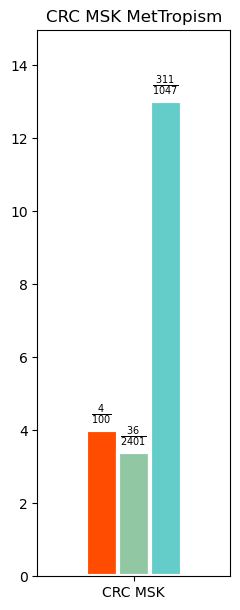

In [6]:
MSI_MSK_plot, MSI_MSK_ax = plt.subplots()

# Set bar colors
# my_colors_MSI = list(islice(cycle(['#FF4C00', '#91C7A3', '#64CCC9']), None, MSIpr_df.size))

MSI_MSK_ax = MSI_MSK_pr_df.plot(legend=False, kind='bar', figsize=(2.5,6), ax=MSI_MSK_ax, color=['#FF4C00', '#91C7A3', '#64CCC9'], width=0.75, edgecolor='white', linewidth=3)

# Rotating X-axis labels
MSI_MSK_ax.tick_params(axis='x', labelrotation = 0)

# Add numerical labels on top of each bar

# Get the x positions of the bars
bars = MSI_MSK_ax.patches  # Each bar is a patch object
MSI_MSK_x_positions = [bar.get_x() + bar.get_width() / 2 for bar in bars]
MSI_MSK_x_positions.sort()

for i, value in enumerate(MSI_MSK_pr_list):
  MSI_MSK_ax.text(MSI_MSK_x_positions[i], value + 0.1, '$\\frac{%d}{%d}$' % (MSI_MSK_am_list[i], MSI_MSK_nos_list[i]), ha='center', va='bottom', fontsize=10)

# MSI_MSK_ax.margins(.15)
MSI_MSK_ax.margins(x=0.02, y=0.15) # Changed the x margin to 0.02, y margin remains same.
# MSI_MSK_ax.set_ylabel('Prevalence (%)', fontsize=12, rotation='vertical', labelpad=15)
MSI_MSK_ax.set_xlabel('', fontsize=12, labelpad=10)
plt.tight_layout()  # Add this line to adjust the layout
MSI_MSK_ax.set_xmargin(0.02) # explicitly set the x margin of the axes.
MSI_MSK_ax.set_xlim(left=MSI_MSK_x_positions[0] - 0.5, right=MSI_MSK_x_positions[-1] + 0.5) # Set the x limits

plt.title('CRC MSK MetTropism')

### MSK-MetTropism Statistic Test

In [7]:
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

# Extract Counts with MSI and with MSS
MSK_BM_MSI = MSI_MSK_am_df.loc['CRC MSK', '# MSI-H in BM']
MSK_BM_MSS = df_nos.loc['CRC_MSK', 'BM total - MSI'] - MSK_BM_MSI
MSK_nBM_MSI = MSI_MSK_am_df.loc['CRC MSK', '# MSI-H in nBM']
MSK_nBM_MSS = df_nos.loc['CRC_MSK', 'nBM total - MSI'] - MSK_nBM_MSI
MSK_LB_MSI = MSI_MSK_am_df.loc['CRC MSK', '# MSI-H in LB']
MSK_LB_MSS = df_nos.loc['CRC_MSK', 'LB total - MSI'] - MSK_LB_MSI


# 2x2 Contingency Tables
MSK_BM_nBM = [
    [MSK_BM_MSI, MSK_BM_MSS],
    [MSK_nBM_MSI, MSK_nBM_MSS]
]
MSK_BM_LB = [
    [MSK_BM_MSI, MSK_BM_MSS],
    [MSK_LB_MSI, MSK_LB_MSS]
]

print(pd.DataFrame(MSK_BM_nBM))
print(pd.DataFrame(MSK_BM_LB))


# Compute raw p-values
pval_MSK_BM_nBM = fisher_exact(MSK_BM_nBM)[1]
pval_MSK_BM_LB = fisher_exact(MSK_BM_LB)[1]

pvals_MSK = [pval_MSK_BM_nBM, pval_MSK_BM_LB]

# Apply FDR correction (Benjamini-Hochberg)
rejected, pvals_corrected, _, _ = multipletests(pvals_MSK, alpha=0.05, method='fdr_bh')

# Display results
print("\nTest 1: MSK BM vs nBM")
print("Test 2: MSK BM vs LB\n")
for i, (raw, corr, reject) in enumerate(zip(pvals_MSK, pvals_corrected, rejected), 1):
    print(f"Test {i}: Raw p = {raw:.4f}, Corrected p = {corr:.4f}, Significant: {reject}")

    0     1
0   4    96
1  36  1011
     0     1
0    4    96
1  311  2090

Test 1: MSK BM vs nBM
Test 2: MSK BM vs LB

Test 1: Raw p = 0.7728, Corrected p = 0.7728, Significant: False
Test 2: Raw p = 0.0052, Corrected p = 0.0103, Significant: True
